<a href="https://colab.research.google.com/github/towbsss/badminton/blob/main/Badminton_Flick_Serve_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Doubles Service Simulation (Simplified)
- Simulating serve and serve returns in doubles
- Only includes short and long (flick serves)
- Wide serves or drive serves are NOT included

## Version 1
- Preliminary Draft of Scores

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & FLEXIBLE PROBABILITIES
# ==========================================

# Probability of a flick serve based on receiver position (0 to 3)
# The closer they stand (0), the higher the chance of a flick.
FLICK_PROBABILITY = {
    0: 0.35,  # 35% chance of flick if right on the line
    1: 0.20,  # 20%
    2: 0.10,  # 10%
    3: 0.05   # 5% chance if they are already far back
}

# Base advantage given the receiver's position AND the actual serve type
# Values based on prompt logic (e.g., pos 0 for Short is +1, Pos 1 for Flick is +2)
POSITION_EFFECT = {
    'SHORT': {
        0: 1,   # Best position for short serve
        1: 0,   # Neutral
        2: -1,  # Getting late
        3: -2   # Way too far back for a short serve
    },
    'FLICK': {
        0: 1,   # Hard to backpedal, but doable if guessed right
        1: 2,   # Ideal position to intercept a flick
        2: 1,   # A bit far back, but easy to reach
        3: 0    # Too far back, lose the offensive advantage
    }
}

# Modifiers for other conditions
GUESS_MODIFIER = {
    True: 0,    # Guessed correctly (baseline expectations apply)
    False: -2   # Guessed incorrectly (severe penalty to return quality)
}

QUALITY_MODIFIER = {
    1: 0,   # Perfect serve (baseline)
    2: 1,   # Slightly loose (Receiver gains +1 advantage)
    3: 2    # Very loose (Receiver gains +2 advantage)
}

# Outcome translator
def translate_score(score):
    if score >= 2: return "Receiver Wins"
    if score == 1: return "Receiver Advantage (Slight Attack)"
    if score == 0: return "Neutral"
    if score == -1: return "Server Advantage (Forced Lift)"
    if score <= -2: return "Server Wins"

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guessed_serve, actual_serve, serve_quality):
    """
    Calculates the outcome of a serve return based on our mapped variables.
    """
    # 0 represents a service error, instant win for receiver
    if serve_quality == 0:
        return 3, "Receiver Wins (Service Error)"

    # Calculate modifiers
    pos_score = POSITION_EFFECT[actual_serve][position]
    guess_correct = (guessed_serve == actual_serve)
    guess_score = GUESS_MODIFIER[guess_correct]
    qual_score = QUALITY_MODIFIER[serve_quality]

    # Sum the scores
    total_score = pos_score + guess_score + qual_score

    return total_score, translate_score(total_score)

# ==========================================
# 3. MAPPING OUT THE CONDITIONS (TABLE)
# ==========================================

def print_condition_matrix():
    print("=========================================================================================")
    print("                        BADMINTON DOUBLES SERVE/RECEIVE MATRIX                           ")
    print("=========================================================================================")
    print(f"{'Pos':<4} | {'Guess':<6} | {'Serve':<6} | {'Qual':<4} || {'Score':<5} | {'Outcome Outcome':<35}")
    print("-" * 85)

    serve_types = ['SHORT', 'FLICK']
    qualities = [1, 2, 3] # Skipping 0 (Error) for the table to keep it concise

    for pos in range(4):
        for guess in serve_types:
            for serve in serve_types:
                for qual in qualities:
                    score, outcome = evaluate_return(pos, guess, serve, qual)

                    # Highlight user's specific prompt examples with a '*'
                    marker = " "
                    if pos == 0 and guess == 'SHORT' and serve == 'SHORT' and qual == 1: marker = "*"
                    if pos == 0 and guess == 'SHORT' and serve == 'SHORT' and qual == 2: marker = "*"
                    if pos == 0 and guess == 'FLICK' and serve == 'FLICK' and qual == 1: marker = "*"
                    if pos == 1 and guess == 'FLICK' and serve == 'FLICK' and qual == 1: marker = "*"

                    print(f"{pos:<4} | {guess:<6} | {serve:<6} | {qual:<4} || {score:<5} | {marker} {outcome:<35}")
        print("-" * 85)

# ==========================================
# 4. SIMULATION SKELETON
# ==========================================
# (This is ready to use once we are happy with the logic mapping above)

def simulate_rally(receiver_position, receiver_guess_prob_short=0.5):
    """
    Simulates a single rally using random numbers and our configuration.
    """
    # 1. Receiver makes a guess
    guess = 'SHORT' if random.random() < receiver_guess_prob_short else 'FLICK'

    # 2. Server decides serve type based on receiver position
    serve = 'FLICK' if random.random() < FLICK_PROBABILITY[receiver_position] else 'SHORT'

    # 3. Server executes (Randomly weighted for now: 5% Error, 40% Perfect, 40% Loose, 15% Very Loose)
    # You can easily change these weights later based on "Server Skill Level"
    quality = random.choices(
        population=[0, 1, 2, 3],
        weights=[0.05, 0.40, 0.40, 0.15],
        k=1
    )[0]

    # 4. Evaluate
    score, outcome = evaluate_return(receiver_position, guess, serve, quality)
    return outcome

def run_simulation(trials=1000, position=0):
    print(f"\nRunning {trials} simulations for Receiver at Position {position}...")
    results = {}

    for _ in range(trials):
        outcome = simulate_rally(position, receiver_guess_prob_short=0.5)
        results[outcome] = results.get(outcome, 0) + 1

    for outcome, count in sorted(results.items()):
        percentage = (count / trials) * 100
        print(f"{percentage:>5.1f}% : {outcome}")

if __name__ == "__main__":
    # First, let's output the matrix so we can verify the logic matches your requirements.
    print_condition_matrix()

    # Run a quick example simulation for position 0
    run_simulation(trials=1000, position=0)
    run_simulation(trials=1000, position=3)

                        BADMINTON DOUBLES SERVE/RECEIVE MATRIX                           
Pos  | Guess  | Serve  | Qual || Score | Outcome Outcome                    
-------------------------------------------------------------------------------------
0    | SHORT  | SHORT  | 1    || 1     | * Receiver Advantage (Slight Attack) 
0    | SHORT  | SHORT  | 2    || 2     | * Receiver Wins                      
0    | SHORT  | SHORT  | 3    || 3     |   Receiver Wins                      
0    | SHORT  | FLICK  | 1    || -1    |   Server Advantage (Forced Lift)     
0    | SHORT  | FLICK  | 2    || 0     |   Neutral                            
0    | SHORT  | FLICK  | 3    || 1     |   Receiver Advantage (Slight Attack) 
0    | FLICK  | SHORT  | 1    || -1    |   Server Advantage (Forced Lift)     
0    | FLICK  | SHORT  | 2    || 0     |   Neutral                            
0    | FLICK  | SHORT  | 3    || 1     |   Receiver Advantage (Slight Attack) 
0    | FLICK  | FLICK  | 1    || 1  

## Version 2
- Include guessing condition
- Includes final output range (+5 to -3)

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & FLEXIBLE PROBABILITIES
# ==========================================

# Probability of a SHORT serve based on receiver position (0 to 3)
SHORT_SERVE_PROBABILITY = {
    0: 0.35,  # 35% chance of short serve (65% flick)
    1: 0.55,  # 55% chance of short serve
    2: 0.75,  # 75% chance of short serve
    3: 0.95   # 95% chance of short serve
}

# Base advantage given the receiver's position AND the actual serve type
# Values based on prompt logic (e.g., pos 0 for Short is +1, Pos 1 for Flick is +2)
POSITION_EFFECT = {
    'SHORT': {
        0: 1,   # Best position for short serve
        1: 0,   # Neutral
        2: -1,  # Getting late
        3: -2   # Way too far back for a short serve
    },
    'FLICK': {
        0: -2,  # Huge disadvantage on perfect flick
        1: -1,  # Disadvantage on perfect flick
        2: 0,   # Neutral on perfect flick
        3: 1    # Slight advantage on perfect flick
    }
}

# Modifiers for other conditions
GUESS_MODIFIER = {
    'CORRECT': 1,  # Guessed correctly (+1)
    'REACT': 0,    # No guess, just reacting (0)
    'WRONG': -1    # Guessed incorrectly (-1)
}

QUALITY_MODIFIER = {
    1: 0,   # Perfect serve (baseline)
    2: 1,   # Okay serve (Receiver gains +1 advantage)
    3: 2    # Bad serve (Receiver gains +2 advantage)
}

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guess, actual_serve, serve_quality):
    """
    Calculates the outcome of a serve return based on our mapped variables.
    """
    # 0 represents a service error, instant win for receiver
    if serve_quality == 0:
        return 99 # Using 99 to represent an instant win / service error

    # Calculate modifiers
    pos_score = POSITION_EFFECT[actual_serve][position]

    if guess == 'REACT':
        guess_state = 'REACT'
    elif guess == actual_serve:
        guess_state = 'CORRECT'
    else:
        guess_state = 'WRONG'

    guess_score = GUESS_MODIFIER[guess_state]
    qual_score = QUALITY_MODIFIER[serve_quality]

    # Sum the scores
    total_score = pos_score + guess_score + qual_score

    return total_score

# ==========================================
# 3. MAPPING OUT THE CONDITIONS (TABLE)
# ==========================================

def print_score_ranges():
    print("=========================================================================================")
    print("                           SCORE RANGE & COMBINATIONS                                    ")
    print("=========================================================================================")

    score_combinations = {}
    serve_types = ['SHORT', 'FLICK']
    guesses = ['SHORT', 'FLICK', 'REACT']
    qualities = [1, 2, 3]

    for pos in range(4):
        for guess in guesses:
            for serve in serve_types:
                for qual in qualities:
                    score = evaluate_return(pos, guess, serve, qual)
                    combo_str = f"Pos {pos} | Guess {guess:<5} | Serve {serve:<5} | Qual {qual}"
                    if score not in score_combinations:
                        score_combinations[score] = []
                    score_combinations[score].append(combo_str)

    for score in sorted(score_combinations.keys(), reverse=True):
        print(f"\nSCORE: {score}")
        print("-" * 40)
        # Print just a few examples for each score
        for combo in score_combinations[score][:4]:
            print(f"  - {combo}")
        if len(score_combinations[score]) > 4:
            print(f"  ... and {len(score_combinations[score]) - 4} other combinations")

# ==========================================
# 4. SIMULATION SKELETON
# ==========================================

def simulate_rally(receiver_position):
    """
    Simulates a single rally using random numbers and our configuration.
    """
    # 1. Receiver makes a guess (Example weights: 40% Short, 40% React, 20% Flick)
    guess = random.choices(
        population=['SHORT', 'REACT', 'FLICK'],
        weights=[0.4, 0.4, 0.2],
        k=1
    )[0]

    # 2. Server decides serve type based on receiver position
    if random.random() < SHORT_SERVE_PROBABILITY[receiver_position]:
        serve = 'SHORT'
    else:
        serve = 'FLICK'

    # 3. Server executes (5% Error, 40% Perfect, 40% Okay, 15% Bad)
    quality = random.choices(
        population=[0, 1, 2, 3],
        weights=[0.05, 0.40, 0.40, 0.15],
        k=1
    )[0]

    # 4. Evaluate
    score = evaluate_return(receiver_position, guess, serve, quality)
    return score

def run_simulation(trials=1000, position=0):
    print(f"\nRunning {trials} simulations for Receiver at Position {position}...")
    results = {}

    for _ in range(trials):
        score = simulate_rally(position)
        results[score] = results.get(score, 0) + 1

    print(f"{'Score':<6} | {'Frequency':<10} | {'% of Rallies':<10}")
    print("-" * 35)
    for score, count in sorted(results.items(), reverse=True):
        percentage = (count / trials) * 100
        score_label = "Error" if score == 99 else str(score)
        print(f"{score_label:<6} | {count:<10} | {percentage:>5.1f}%")

if __name__ == "__main__":
    # First, show all possible scores and how to achieve them
    print_score_ranges()

    # Then, simulate to show how frequently these scores happen organically
    run_simulation(trials=10000, position=0)
    run_simulation(trials=10000, position=3)

                           SCORE RANGE & COMBINATIONS                                    

SCORE: 4
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 3 | Guess FLICK | Serve FLICK | Qual 3

SCORE: 3
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 2
  - Pos 0 | Guess REACT | Serve SHORT | Qual 3
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 2 | Guess FLICK | Serve FLICK | Qual 3
  ... and 2 other combinations

SCORE: 2
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 1
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 2
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 2
  ... and 8 other combinations

SCORE: 1
----------------------------------------
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 2
  - Pos 0 | Guess FLICK | Serve FLICK | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 1
  - Pos 1 | Guess SHORT | Serve S

## Version 3
- Include serve and serve return errors and rates

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & FLEXIBLE PROBABILITIES
# ==========================================

# Probability of a SHORT serve based on receiver position (0 to 3)
SHORT_SERVE_PROBABILITY = {
    0: 0.35,  # 35% chance of short serve (65% flick)
    1: 0.55,  # 55% chance of short serve
    2: 0.75,  # 75% chance of short serve
    3: 0.95   # 95% chance of short serve
}

# Base advantage given the receiver's position AND the actual serve type
# Values based on prompt logic (e.g., pos 0 for Short is +1, Pos 1 for Flick is +2)
POSITION_EFFECT = {
    'SHORT': {
        0: 1,   # Best position for short serve
        1: 0,   # Neutral
        2: -1,  # Getting late
        3: -2   # Way too far back for a short serve
    },
    'FLICK': {
        0: -2,  # Huge disadvantage on perfect flick
        1: -1,  # Disadvantage on perfect flick
        2: 0,   # Neutral on perfect flick
        3: 1    # Slight advantage on perfect flick
    }
}

# Modifiers for other conditions
GUESS_MODIFIER = {
    'CORRECT': 1,  # Guessed correctly (+1)
    'REACT': 0,    # No guess, just reacting (0)
    'WRONG': -1    # Guessed incorrectly (-1)
}

QUALITY_MODIFIER = {
    0: 5,   # Service Error (Instant Receiver Win)
    1: 0,   # Perfect serve (baseline)
    2: 1,   # Okay serve (Receiver gains +1 advantage)
    3: 2    # Bad serve (Receiver gains +2 advantage)
}

# Player Level Adjustments (Error Rates)
SERVER_ERROR_RATE = 0.10
RECEIVER_SHORT_ERROR_RATE = 0.10
RECEIVER_FLICK_ERROR_RATE = 0.10

SCORE_LABELS = {
    5: "Server Error (Receiver Wins)",
    4: "Instant Receiver Win",
    3: "Massive Advantage (Easy Put-away)",
    2: "Strong Advantage (Attacking Position)",
    1: "Slight Advantage (Initiative)",
    0: "Neutral (Flat Exchange)",
    -1: "Disadvantage (Forced Defense)",
    -2: "Instant Receiver Loss (Ace / Forced Error)",
    -3: "Receiver Unforced Error (Server Wins)"
}

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guess, actual_serve, serve_quality):
    """
    Calculates the outcome of a serve return based on our mapped variables.
    """
    # 5 represents a service error, instant win for receiver
    if serve_quality == 0:
        return 5

    # Calculate modifiers
    pos_score = POSITION_EFFECT[actual_serve][position]

    if guess == 'REACT':
        guess_state = 'REACT'
    elif guess == actual_serve:
        guess_state = 'CORRECT'
    else:
        guess_state = 'WRONG'

    guess_score = GUESS_MODIFIER[guess_state]
    qual_score = QUALITY_MODIFIER[serve_quality]

    # Sum the scores and clamp them between -2 and 4 to fit our logical labels
    total_score = pos_score + guess_score + qual_score
    total_score = max(-2, min(4, total_score))

    return total_score

# ==========================================
# 3. MAPPING OUT THE CONDITIONS (TABLE)
# ==========================================

def print_score_ranges():
    print("=========================================================================================")
    print("                           SCORE RANGE & COMBINATIONS                                    ")
    print("=========================================================================================")

    score_combinations = {}
    serve_types = ['SHORT', 'FLICK']
    guesses = ['SHORT', 'FLICK', 'REACT']
    qualities = [1, 2, 3] # Exclude 0 here so we only see organic rally permutations

    for pos in range(4):
        for guess in guesses:
            for serve in serve_types:
                for qual in qualities:
                    score = evaluate_return(pos, guess, serve, qual)
                    combo_str = f"Pos {pos} | Guess {guess:<5} | Serve {serve:<5} | Qual {qual}"
                    if score not in score_combinations:
                        score_combinations[score] = []
                    score_combinations[score].append(combo_str)

    for score in sorted(score_combinations.keys(), reverse=True):
        print(f"\nSCORE: {score}")
        print("-" * 40)
        # Print just a few examples for each score
        for combo in score_combinations[score][:4]:
            print(f"  - {combo}")
        if len(score_combinations[score]) > 4:
            print(f"  ... and {len(score_combinations[score]) - 4} other combinations")

# ==========================================
# 4. SIMULATION SKELETON
# ==========================================

def simulate_rally(receiver_position):
    """
    Simulates a single rally using random numbers and our configuration.
    """
    # 1. Receiver makes a guess (Example weights: 40% Short, 40% React, 20% Flick)
    guess = random.choices(
        population=['SHORT', 'REACT', 'FLICK'],
        weights=[0.4, 0.4, 0.2],
        k=1
    )[0]

    # 2. Server decides serve type based on receiver position
    if random.random() < SHORT_SERVE_PROBABILITY[receiver_position]:
        serve = 'SHORT'
    else:
        serve = 'FLICK'

    # 3. Server executes
    # Probabilities adjust based on SERVER_ERROR_RATE so we can simulate different skill levels
    remaining_prob = 1.0 - SERVER_ERROR_RATE
    quality = random.choices(
        population=[0, 1, 2, 3],
        weights=[SERVER_ERROR_RATE, remaining_prob * 0.45, remaining_prob * 0.40, remaining_prob * 0.15],
        k=1
    )[0]

    # 4. Evaluate situational advantage
    score = evaluate_return(receiver_position, guess, serve, quality)

    # 5. Check for Receiver Unforced Error
    # Only happens if the serve was in play (not a 5) and the receiver could reach it (not a -2)
    if -1 <= score <= 4:
        error_rate = RECEIVER_SHORT_ERROR_RATE if serve == 'SHORT' else RECEIVER_FLICK_ERROR_RATE
        if random.random() < error_rate:
            score = -3 # Receiver Unforced Error

    return score

def run_simulation(trials=1000, position=0):
    print(f"\nRunning {trials} simulations for Receiver at Position {position}...")
    results = {}

    for _ in range(trials):
        score = simulate_rally(position)
        results[score] = results.get(score, 0) + 1

    print(f"{'Score':<6} | {'Outcome Label':<40} | {'Frequency':<10} | {'% of Rallies':<10}")
    print("-" * 75)
    for score, count in sorted(results.items(), reverse=True):
        percentage = (count / trials) * 100
        label = SCORE_LABELS.get(score, "Unknown")
        print(f"{score:<6} | {label:<40} | {count:<10} | {percentage:>5.1f}%")

if __name__ == "__main__":
    # First, show all possible scores and how to achieve them
    print_score_ranges()

    # Then, simulate to show how frequently these scores happen organically
    run_simulation(trials=10000, position=0)
    run_simulation(trials=10000, position=3)

                           SCORE RANGE & COMBINATIONS                                    

SCORE: 4
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 3 | Guess FLICK | Serve FLICK | Qual 3

SCORE: 3
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 2
  - Pos 0 | Guess REACT | Serve SHORT | Qual 3
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 2 | Guess FLICK | Serve FLICK | Qual 3
  ... and 2 other combinations

SCORE: 2
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 1
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 2
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 2
  ... and 8 other combinations

SCORE: 1
----------------------------------------
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 2
  - Pos 0 | Guess FLICK | Serve FLICK | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 1
  - Pos 1 | Guess SHORT | Serve S

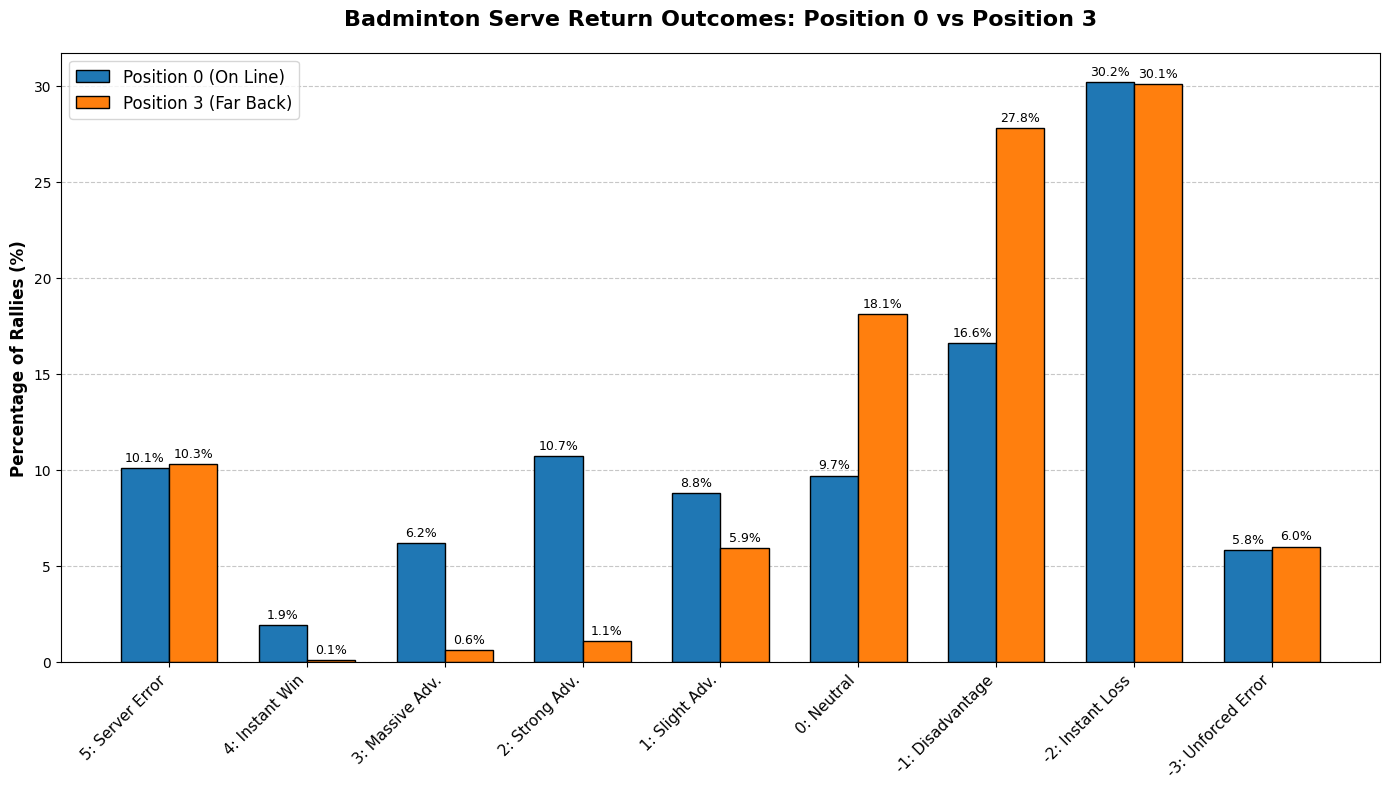

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the 10,000 simulations
labels = [
    "5: Server Error",
    "4: Instant Win",
    "3: Massive Adv.",
    "2: Strong Adv.",
    "1: Slight Adv.",
    "0: Neutral",
    "-1: Disadvantage",
    "-2: Instant Loss",
    "-3: Unforced Error"
]

# Percentages mapped from the simulation output
pos_0_pct = [10.1, 1.9, 6.2, 10.7, 8.8, 9.7, 16.6, 30.2, 5.8]
pos_3_pct = [10.3, 0.1, 0.6, 1.1, 5.9, 18.1, 27.8, 30.1, 6.0]

x = np.arange(len(labels))  # The label locations
width = 0.35  # The width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot bars for both positions
rects1 = ax.bar(x - width/2, pos_0_pct, width, label='Position 0 (On Line)', color='#1f77b4', edgecolor='black')
rects2 = ax.bar(x + width/2, pos_3_pct, width, label='Position 3 (Far Back)', color='#ff7f0e', edgecolor='black')

# Add text, titles, and custom axes
ax.set_ylabel('Percentage of Rallies (%)', fontsize=12, fontweight='bold')
ax.set_title('Badminton Serve Return Outcomes: Position 0 vs Position 3', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)

# Add gridlines for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Function to auto-label the heights of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

# Display the chart
plt.show()

## Version 4 (Dynamic Simulation)
- Includes changes based on the result of a previous serve/serve return outcome if the receiver loses.

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & PROBABILITIES
# ==========================================

SHORT_SERVE_PROBABILITY = { 0: 0.35, 1: 0.55, 2: 0.75, 3: 0.95 }

POSITION_EFFECT = {
    'SHORT': { 0: 1, 1: 0, 2: -1, 3: -2 },
    'FLICK': { 0: -2, 1: -1, 2: 0, 3: 1 }
}

GUESS_MODIFIER = { 'CORRECT': 1, 'REACT': 0, 'WRONG': -1 }

QUALITY_MODIFIER = { 0: 5, 1: 0, 2: 1, 3: 2 }

SERVER_ERROR_RATE = 0.10
RECEIVER_SHORT_ERROR_RATE = 0.10
RECEIVER_FLICK_ERROR_RATE = 0.10

SCORE_LABELS = {
    5: "Server Error", 4: "Instant Win", 3: "Massive Adv.", 2: "Strong Adv.",
    1: "Slight Adv.", 0: "Neutral", -1: "Disadvantage", -2: "Instant Loss", -3: "Unforced Error"
}

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guess, actual_serve, serve_quality):
    if serve_quality == 0: return 5

    pos_score = POSITION_EFFECT[actual_serve][position]

    if guess == 'REACT': guess_state = 'REACT'
    elif guess == actual_serve: guess_state = 'CORRECT'
    else: guess_state = 'WRONG'

    guess_score = GUESS_MODIFIER[guess_state]
    qual_score = QUALITY_MODIFIER[serve_quality]

    total_score = max(-2, min(4, pos_score + guess_score + qual_score))
    return total_score

# ==========================================
# 3. DYNAMIC SIMULATION ENGINE
# ==========================================

def simulate_dynamic_rally(current_position):
    """Simulates a single rally and returns the score and the serve type."""
    guess = random.choices(['SHORT', 'REACT', 'FLICK'], weights=[0.4, 0.4, 0.2], k=1)[0]

    serve = 'SHORT' if random.random() < SHORT_SERVE_PROBABILITY[current_position] else 'FLICK'

    remaining_prob = 1.0 - SERVER_ERROR_RATE
    quality = random.choices(
        [0, 1, 2, 3],
        weights=[SERVER_ERROR_RATE, remaining_prob * 0.45, remaining_prob * 0.40, remaining_prob * 0.15],
        k=1
    )[0]

    score = evaluate_return(current_position, guess, serve, quality)

    if -1 <= score <= 4:
        error_rate = RECEIVER_SHORT_ERROR_RATE if serve == 'SHORT' else RECEIVER_FLICK_ERROR_RATE
        if random.random() < error_rate:
            score = -3 # Receiver Unforced Error

    return score, serve

def run_dynamic_match(total_rallies=10000, starting_position=0):
    print(f"\nRunning dynamic match of {total_rallies} serves (Starting Pos: {starting_position})...")

    current_position = starting_position

    # Trackers
    score_results = {}
    position_history = {0: 0, 1: 0, 2: 0, 3: 0}

    for _ in range(total_rallies):
        # 1. Log the position they chose for this rally
        position_history[current_position] += 1

        # 2. Play the rally
        score, serve_type = simulate_dynamic_rally(current_position)
        score_results[score] = score_results.get(score, 0) + 1

        # 3. Adjust position for the NEXT rally based on outcome
        # If score is -1, -2, or -3, they lost/were disadvantaged
        if score <= -1:
            if serve_type == 'FLICK':
                # Got flicked and lost -> back up a step
                current_position = min(3, current_position + 1)
            elif serve_type == 'SHORT':
                # Got served short and lost -> move forward a step
                current_position = max(0, current_position - 1)
        # If score >= 0, they hold their ground!

    # Print Results
    print("\n--- POSITION PREFERENCE OVER MATCH ---")
    for pos, count in position_history.items():
        print(f"Position {pos}: {count/total_rallies * 100:>5.1f}% of the time")

    print("\n--- OVERALL SCORE FREQUENCY ---")
    for score, count in sorted(score_results.items(), reverse=True):
        label = SCORE_LABELS.get(score, "Unknown")
        print(f"{score:<3} | {label:<15} | {count/total_rallies * 100:>5.1f}%")

if __name__ == "__main__":
    run_dynamic_match(total_rallies=10000, starting_position=1)


Running dynamic match of 10000 serves (Starting Pos: 1)...

--- POSITION PREFERENCE OVER MATCH ---
Position 0:   8.6% of the time
Position 1:  48.3% of the time
Position 2:  39.4% of the time
Position 3:   3.6% of the time

--- OVERALL SCORE FREQUENCY ---
5   | Server Error    |  10.3%
4   | Instant Win     |   0.1%
3   | Massive Adv.    |   2.0%
2   | Strong Adv.     |   8.4%
1   | Slight Adv.     |  18.9%
0   | Neutral         |  24.7%
-1  | Disadvantage    |  17.6%
-2  | Instant Loss    |   9.7%
-3  | Unforced Error  |   8.3%


## Version 5
- Include visualizations

Generating Comparative Static Chart...


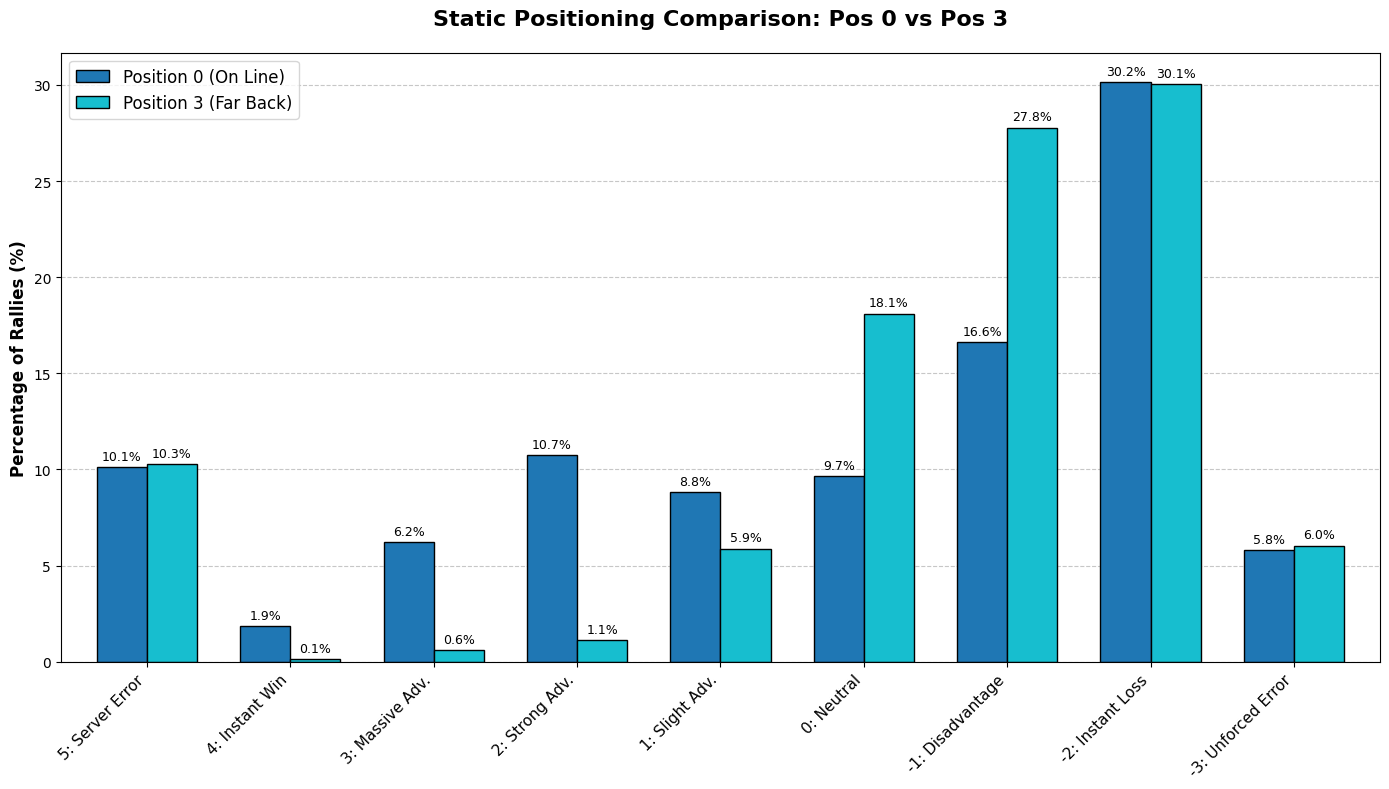


Pandas DataFrame mapped from Static Data:
                    Position 0 (On Line)  Position 3 (Far Back)
5: Server Error                     10.1                   10.3
4: Instant Win                       1.9                    0.1
3: Massive Adv.                      6.2                    0.6
2: Strong Adv.                      10.7                    1.1
1: Slight Adv.                       8.8                    5.9
0: Neutral                           9.7                   18.1
-1: Disadvantage                    16.6                   27.8
-2: Instant Loss                    30.2                   30.1
-3: Unforced Error                   5.8                    6.0

Generating Dynamic Match Chart...


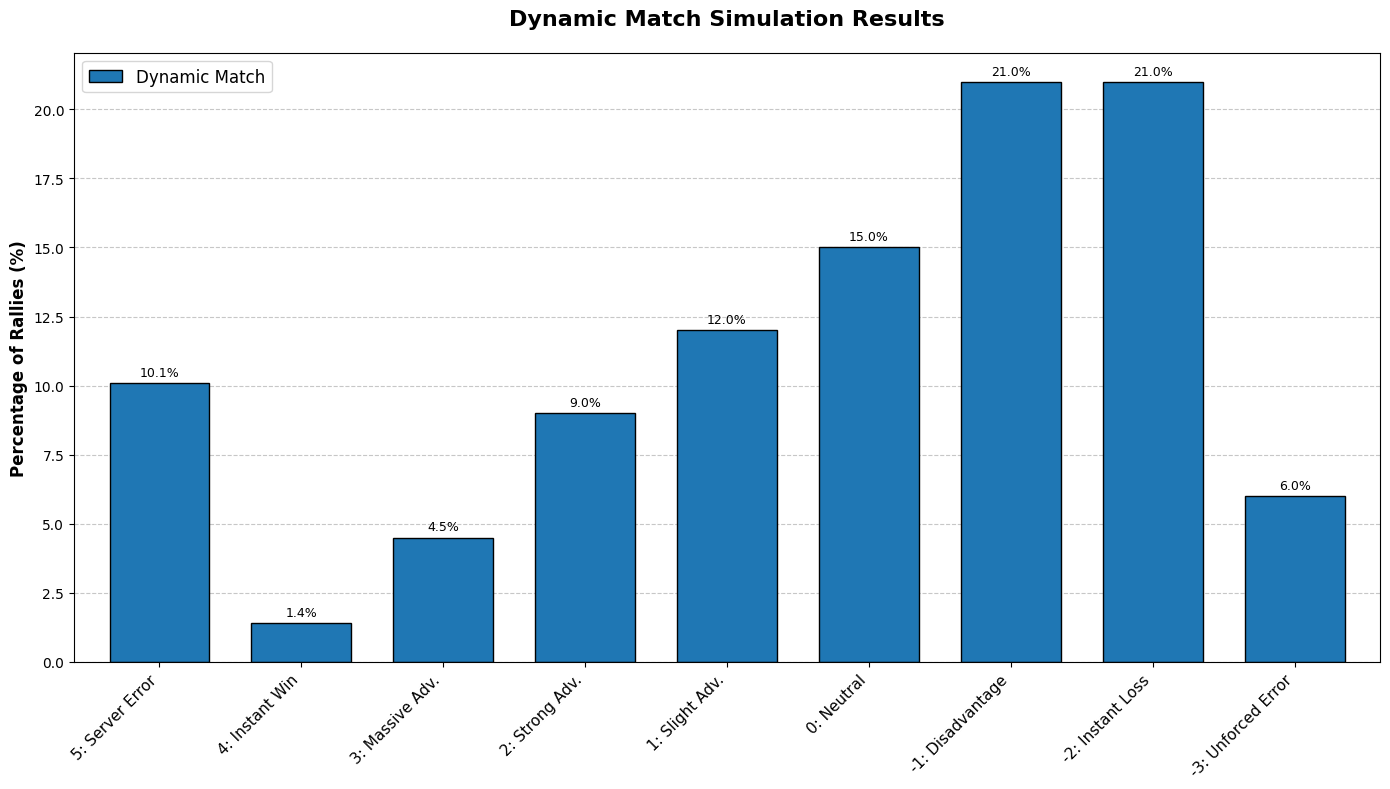


Pandas DataFrame mapped from Dynamic Data:
                    Dynamic Match
5: Server Error              10.1
4: Instant Win                1.4
3: Massive Adv.               4.5
2: Strong Adv.                9.0
1: Slight Adv.               12.0
0: Neutral                   15.0
-1: Disadvantage             21.0
-2: Instant Loss             21.0
-3: Unforced Error            6.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Using the exact labels from your simulation
SCORE_LABELS = {
    5: "Server Error",
    4: "Instant Win",
    3: "Massive Adv.",
    2: "Strong Adv.",
    1: "Slight Adv.",
    0: "Neutral",
    -1: "Disadvantage",
    -2: "Instant Loss",
    -3: "Unforced Error"
}

def visualize_simulations(simulations_data, title="Badminton Serve Return Outcomes"):
    """
    Takes a dictionary of simulation results, converts to a pandas DataFrame,
    calculates percentages, and generates a bar chart.

    Expected format for simulations_data:
    {
        "Position 0 (Static)": {5: 1011, 4: 186, ...},
        "Position 3 (Static)": {5: 1029, 4: 13, ...}
    }
    OR
    {
        "Dynamic Match Results": {5: 980, 4: 150, ...}
    }
    """

    # 1. Map data to a Pandas DataFrame
    # Missing scores in any dataset will be filled with 0
    df = pd.DataFrame(simulations_data).fillna(0)

    # 2. Convert raw counts to percentages for each column
    for col in df.columns:
        total = df[col].sum()
        if total > 0:
            df[col] = (df[col] / total) * 100

    # 3. Sort index descending so +5 is on the left and -3 is on the right
    df = df.sort_index(ascending=False)

    # 4. Map the integer index to our readable labels
    df.index = df.index.map(lambda x: f"{x}: {SCORE_LABELS.get(x, 'Unknown')}")

    # --- VISUALIZATION ---

    # Plot directly from the DataFrame
    ax = df.plot(kind='bar', figsize=(14, 8), width=0.7, edgecolor='black', colormap='tab10')

    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Percentage of Rallies (%)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_axisbelow(True) # Push gridlines behind bars

    # Auto-label the heights of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Only label bars that actually have data
            ax.annotate(f'{height:.1f}%',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Return the dataframe so you can print or inspect the raw table in Colab
    return df

if __name__ == "__main__":
    # EXAMPLE 1: Comparing two static positions (like your first simulations)
    static_data = {
        "Position 0 (On Line)": {5: 1011, 4: 186, 3: 623, 2: 1074, 1: 881, 0: 966, -1: 1664, -2: 3016, -3: 579},
        "Position 3 (Far Back)": {5: 1029, 4: 13, 3: 59, 2: 111, 1: 589, 0: 1811, -1: 2778, -2: 3006, -3: 604}
    }

    print("Generating Comparative Static Chart...")
    df_static = visualize_simulations(static_data, "Static Positioning Comparison: Pos 0 vs Pos 3")
    print("\nPandas DataFrame mapped from Static Data:")
    print(df_static.round(1))

    # EXAMPLE 2: Visualizing a single dynamic match
    dynamic_data = {
        # Using dummy data to represent what 'score_results' from your dynamic script looks like
        "Dynamic Match": {5: 1010, 4: 140, 3: 450, 2: 900, 1: 1200, 0: 1500, -1: 2100, -2: 2100, -3: 600}
    }

    print("\nGenerating Dynamic Match Chart...")
    df_dynamic = visualize_simulations(dynamic_data, "Dynamic Match Simulation Results")
    print("\nPandas DataFrame mapped from Dynamic Data:")
    print(df_dynamic.round(1))

## Version 7
- `badminton_simulation.py`
- `dynamic_simulation.py`
- `colab_visualization.py`

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & FLEXIBLE PROBABILITIES
# ==========================================

# Probability of a SHORT serve based on receiver position (0 to 3)
SHORT_SERVE_PROBABILITY = {
    0: 0.35,  # 35% chance of short serve (65% flick)
    1: 0.55,  # 55% chance of short serve
    2: 0.75,  # 75% chance of short serve
    3: 0.95   # 95% chance of short serve
}

# Base advantage given the receiver's position AND the actual serve type
# Values based on prompt logic (e.g., pos 0 for Short is +1, Pos 1 for Flick is +2)
POSITION_EFFECT = {
    'SHORT': {
        0: 1,   # Best position for short serve
        1: 0,   # Neutral
        2: -1,  # Getting late
        3: -2   # Way too far back for a short serve
    },
    'FLICK': {
        0: -2,  # Huge disadvantage on perfect flick
        1: -1,  # Disadvantage on perfect flick
        2: 0,   # Neutral on perfect flick
        3: 1    # Slight advantage on perfect flick
    }
}

# Modifiers for other conditions
GUESS_MODIFIER = {
    'CORRECT': 1,  # Guessed correctly (+1)
    'REACT': 0,    # No guess, just reacting (0)
    'WRONG': -1    # Guessed incorrectly (-1)
}

QUALITY_MODIFIER = {
    0: 5,   # Service Error (Instant Receiver Win)
    1: 0,   # Perfect serve (baseline)
    2: 1,   # Okay serve (Receiver gains +1 advantage)
    3: 2    # Bad serve (Receiver gains +2 advantage)
}

# Player Level Adjustments (Error Rates)
SERVER_ERROR_RATE = 0.10
RECEIVER_SHORT_ERROR_RATE = 0.10
RECEIVER_FLICK_ERROR_RATE = 0.10

SCORE_LABELS = {
    5: "Server Error (Receiver Wins)",
    4: "Instant Receiver Win",
    3: "Massive Advantage (Easy Put-away)",
    2: "Strong Advantage (Attacking Position)",
    1: "Slight Advantage (Initiative)",
    0: "Neutral (Flat Exchange)",
    -1: "Disadvantage (Forced Defense)",
    -2: "Instant Receiver Loss (Forced Error)",
    -3: "Receiver Unforced Error (Server Wins)"
}

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guess, actual_serve, serve_quality):
    """
    Calculates the outcome of a serve return based on our mapped variables.
    """
    # 5 represents a service error, instant win for receiver
    if serve_quality == 0:
        return 5

    # Calculate modifiers
    pos_score = POSITION_EFFECT[actual_serve][position]

    if guess == 'REACT':
        guess_state = 'REACT'
    elif guess == actual_serve:
        guess_state = 'CORRECT'
    else:
        guess_state = 'WRONG'

    guess_score = GUESS_MODIFIER[guess_state]
    qual_score = QUALITY_MODIFIER[serve_quality]

    # Sum the scores and clamp them between -2 and 4 to fit our logical labels
    total_score = pos_score + guess_score + qual_score
    total_score = max(-2, min(4, total_score))

    return total_score

# ==========================================
# 3. MAPPING OUT THE CONDITIONS (TABLE)
# ==========================================

def print_score_ranges():
    print("=========================================================================================")
    print("                           SCORE RANGE & COMBINATIONS                                    ")
    print("=========================================================================================")

    score_combinations = {}
    serve_types = ['SHORT', 'FLICK']
    guesses = ['SHORT', 'FLICK', 'REACT']
    qualities = [1, 2, 3]

    for pos in range(4):
        for guess in guesses:
            for serve in serve_types:
                for qual in qualities:
                    score = evaluate_return(pos, guess, serve, qual)
                    combo_str = f"Pos {pos} | Guess {guess:<5} | Serve {serve:<5} | Qual {qual}"
                    if score not in score_combinations:
                        score_combinations[score] = []
                    score_combinations[score].append(combo_str)

    for score in sorted(score_combinations.keys(), reverse=True):
        print(f"\nSCORE: {score}")
        print("-" * 40)
        # Print just a few examples for each score
        for combo in score_combinations[score][:4]:
            print(f"  - {combo}")
        if len(score_combinations[score]) > 4:
            print(f"  ... and {len(score_combinations[score]) - 4} other combinations")

# ==========================================
# 4. SIMULATION SKELETON
# ==========================================

def simulate_rally(receiver_position, override_short_prob=None):
    """
    Simulates a single rally using random numbers and our configuration.
    """
    # 1. Receiver makes a guess (Example weights: 40% Short, 40% React, 20% Flick)
    guess = random.choices(
        population=['SHORT', 'REACT', 'FLICK'],
        weights=[0.4, 0.4, 0.2],
        k=1
    )[0]

    # 2. Server decides serve type based on receiver position or adaptation override
    short_prob = override_short_prob if override_short_prob is not None else SHORT_SERVE_PROBABILITY[receiver_position]
    if random.random() < SHORT_SERVE_PROBABILITY[receiver_position]:
        serve = 'SHORT'
    else:
        serve = 'FLICK'

    # 3. Server executes
    # Probabilities adjust based on SERVER_ERROR_RATE so we can simulate different skill levels
    remaining_prob = 1.0 - SERVER_ERROR_RATE
    quality = random.choices(
        population=[0, 1, 2, 3],
        weights=[SERVER_ERROR_RATE, remaining_prob * 0.45, remaining_prob * 0.40, remaining_prob * 0.15],
        k=1
    )[0]

    # 4. Evaluate situational advantage
    score = evaluate_return(receiver_position, guess, serve, quality)

    # 5. Check for Receiver Unforced Error
    # Only happens if the serve was in play (not a 5) and the receiver could reach it (not a -2)
    if -1 <= score <= 4:
        error_rate = RECEIVER_SHORT_ERROR_RATE if serve == 'SHORT' else RECEIVER_FLICK_ERROR_RATE
        if random.random() < error_rate:
            score = -3 # Receiver Unforced Error

    return score

def run_simulation(trials=1000, position=0):
    print(f"\nRunning {trials} simulations for Receiver at Position {position}...")
    results = {}

    for _ in range(trials):
        score = simulate_rally(position)
        results[score] = results.get(score, 0) + 1

    print(f"{'Score':<6} | {'Outcome Label':<40} | {'Frequency':<10} | {'% of Rallies':<10}")
    print("-" * 75)
    for score, count in sorted(results.items(), reverse=True):
        percentage = (count / trials) * 100
        label = SCORE_LABELS.get(score, "Unknown")
        print(f"{score:<6} | {label:<40} | {count:<10} | {percentage:>5.1f}%")

    # Return the dictionary so it can be captured and visualized
    return results

if __name__ == "__main__":
    # First, show all possible scores and how to achieve them
    print_score_ranges()

    # Then, simulate to show how frequently these scores happen organically
    # Capture the returned dictionaries into variables
    results_pos_0 = run_simulation(trials=10000, position=0)
    results_pos_3 = run_simulation(trials=10000, position=3)

    # Map the results to the exact structure the visualization function expects
    static_data = {
        "Position 0 (On Line)": results_pos_0,
        "Position 3 (Far Back)": results_pos_3
    }

    print("\n--- 'static_data' dictionary successfully generated! ---")

    # If you have imported visualize_simulations from your other cell,
    # you can now call it directly like this:
    # visualize_simulations(static_data, "Static Positioning Comparison: Pos 0 vs Pos 3")

                           SCORE RANGE & COMBINATIONS                                    

SCORE: 4
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 3 | Guess FLICK | Serve FLICK | Qual 3

SCORE: 3
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 2
  - Pos 0 | Guess REACT | Serve SHORT | Qual 3
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 3
  - Pos 2 | Guess FLICK | Serve FLICK | Qual 3
  ... and 2 other combinations

SCORE: 2
----------------------------------------
  - Pos 0 | Guess SHORT | Serve SHORT | Qual 1
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 2
  - Pos 1 | Guess SHORT | Serve SHORT | Qual 2
  ... and 8 other combinations

SCORE: 1
----------------------------------------
  - Pos 0 | Guess FLICK | Serve SHORT | Qual 2
  - Pos 0 | Guess FLICK | Serve FLICK | Qual 3
  - Pos 0 | Guess REACT | Serve SHORT | Qual 1
  - Pos 1 | Guess SHORT | Serve S

In [ ]:
import random

# ==========================================
# 1. CONFIGURATION & PROBABILITIES
# ==========================================

SHORT_SERVE_PROBABILITY = { 0: 0.35, 1: 0.55, 2: 0.75, 3: 0.95 }

POSITION_EFFECT = {
    'SHORT': { 0: 1, 1: 0, 2: -1, 3: -2 },
    'FLICK': { 0: -2, 1: -1, 2: 0, 3: 1 }
}

GUESS_MODIFIER = { 'CORRECT': 1, 'REACT': 0, 'WRONG': -1 }

QUALITY_MODIFIER = { 0: 5, 1: 0, 2: 1, 3: 2 }

SERVER_ERROR_RATE = 0.10
RECEIVER_SHORT_ERROR_RATE = 0.10
RECEIVER_FLICK_ERROR_RATE = 0.10

SCORE_LABELS = {
    5: "Server Error", 4: "Instant Win", 3: "Massive Adv.", 2: "Strong Adv.",
    1: "Slight Adv.", 0: "Neutral", -1: "Disadvantage", -2: "Instant Loss", -3: "Unforced Error"
}

# ==========================================
# 2. CORE LOGIC ENGINE
# ==========================================

def evaluate_return(position, guess, actual_serve, serve_quality):
    if serve_quality == 0: return 5

    pos_score = POSITION_EFFECT[actual_serve][position]

    if guess == 'REACT': guess_state = 'REACT'
    elif guess == actual_serve: guess_state = 'CORRECT'
    else: guess_state = 'WRONG'

    guess_score = GUESS_MODIFIER[guess_state]
    qual_score = QUALITY_MODIFIER[serve_quality]

    total_score = max(-2, min(4, pos_score + guess_score + qual_score))
    return total_score

# ==========================================
# 3. DYNAMIC SIMULATION ENGINE
# ==========================================

def simulate_dynamic_rally(current_position):
    """Simulates a single rally and returns the score and the serve type."""
    guess = random.choices(['SHORT', 'REACT', 'FLICK'], weights=[0.4, 0.4, 0.2], k=1)[0]

    serve = 'SHORT' if random.random() < SHORT_SERVE_PROBABILITY[current_position] else 'FLICK'

    remaining_prob = 1.0 - SERVER_ERROR_RATE
    quality = random.choices(
        [0, 1, 2, 3],
        weights=[SERVER_ERROR_RATE, remaining_prob * 0.45, remaining_prob * 0.40, remaining_prob * 0.15],
        k=1
    )[0]

    score = evaluate_return(current_position, guess, serve, quality)

    if -1 <= score <= 4:
        error_rate = RECEIVER_SHORT_ERROR_RATE if serve == 'SHORT' else RECEIVER_FLICK_ERROR_RATE
        if random.random() < error_rate:
            score = -3 # Receiver Unforced Error

    return score, serve

def run_dynamic_match(total_rallies=10000, starting_position=0):
    print(f"\nRunning dynamic match of {total_rallies} serves (Starting Pos: {starting_position})...")

    current_position = starting_position

    # Trackers
    score_results = {}
    position_history = {0: 0, 1: 0, 2: 0, 3: 0}

    for _ in range(total_rallies):
        # 1. Log the position they chose for this rally
        position_history[current_position] += 1

        # 2. Play the rally
        score, serve_type = simulate_dynamic_rally(current_position)
        score_results[score] = score_results.get(score, 0) + 1

        # 3. Adjust position for the NEXT rally based on outcome
        # If score is -1, -2, or -3, they lost/were disadvantaged
        if score <= -1:
            if serve_type == 'FLICK':
                # Got flicked and lost -> back up a step
                current_position = min(3, current_position + 1)
            elif serve_type == 'SHORT':
                # Got served short and lost -> move forward a step
                current_position = max(0, current_position - 1)
        # If score >= 0, they hold their ground!

    # Print Results
    print("\n--- POSITION PREFERENCE OVER MATCH ---")
    for pos, count in position_history.items():
        print(f"Position {pos}: {count/total_rallies * 100:>5.1f}% of the time")

    print("\n--- OVERALL SCORE FREQUENCY ---")
    for score, count in sorted(score_results.items(), reverse=True):
        label = SCORE_LABELS.get(score, "Unknown")
        print(f"{score:<3} | {label:<15} | {count/total_rallies * 100:>5.1f}%")

    return score_results

if __name__ == "__main__":
    # Capture the results into a variable
    dynamic_results = run_dynamic_match(total_rallies=10000, starting_position=1)


Running dynamic match of 10000 serves (Starting Pos: 1)...

--- POSITION PREFERENCE OVER MATCH ---
Position 0:   8.2% of the time
Position 1:  48.7% of the time
Position 2:  39.8% of the time
Position 3:   3.3% of the time

--- OVERALL SCORE FREQUENCY ---
5   | Server Error    |   9.8%
4   | Instant Win     |   0.1%
3   | Massive Adv.    |   2.0%
2   | Strong Adv.     |   8.8%
1   | Slight Adv.     |  19.4%
0   | Neutral         |  24.3%
-1  | Disadvantage    |  18.2%
-2  | Instant Loss    |   9.4%
-3  | Unforced Error  |   8.0%


Running NEW Static Simulations to generate fresh data...

Running 10000 simulations for Receiver at Position 0...
Score  | Outcome Label                            | Frequency  | % of Rallies
---------------------------------------------------------------------------
5      | Server Error                             | 968        |   9.7%
4      | Instant Win                              | 166        |   1.7%
3      | Massive Adv.                             | 604        |   6.0%
2      | Strong Adv.                              | 1013       |  10.1%
1      | Slight Adv.                              | 910        |   9.1%
0      | Neutral                                  | 1014       |  10.1%
-1     | Disadvantage                             | 1713       |  17.1%
-2     | Instant Loss                             | 2988       |  29.9%
-3     | Unforced Error                           | 624        |   6.2%

Running 10000 simulations for Receiver at Position 3...
Score  | Outcome Label     

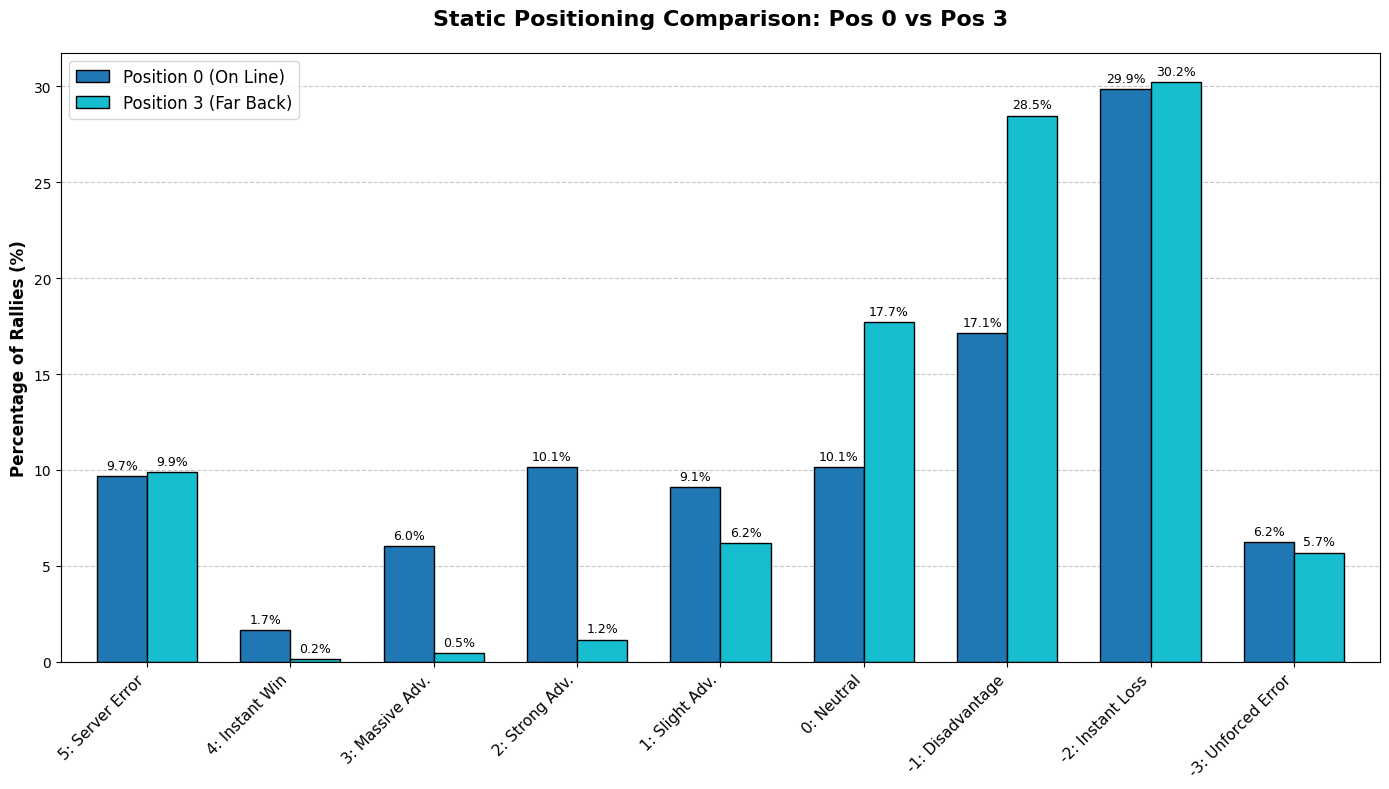


---------------------------------------------------------
Running NEW Dynamic Match Simulation to generate fresh data...

Running dynamic match of 10000 serves (Starting Pos: 1)...

--- POSITION PREFERENCE OVER MATCH ---
Position 0:   9.1% of the time
Position 1:  46.5% of the time
Position 2:  40.8% of the time
Position 3:   3.5% of the time

--- OVERALL SCORE FREQUENCY ---
5   | Server Error    |   9.9%
4   | Instant Win     |   0.2%
3   | Massive Adv.    |   2.2%
2   | Strong Adv.     |   8.5%
1   | Slight Adv.     |  18.4%
0   | Neutral         |  25.1%
-1  | Disadvantage    |  18.2%
-2  | Instant Loss    |   9.2%
-3  | Unforced Error  |   8.2%

Generating Dynamic Match Chart with FRESH Data...


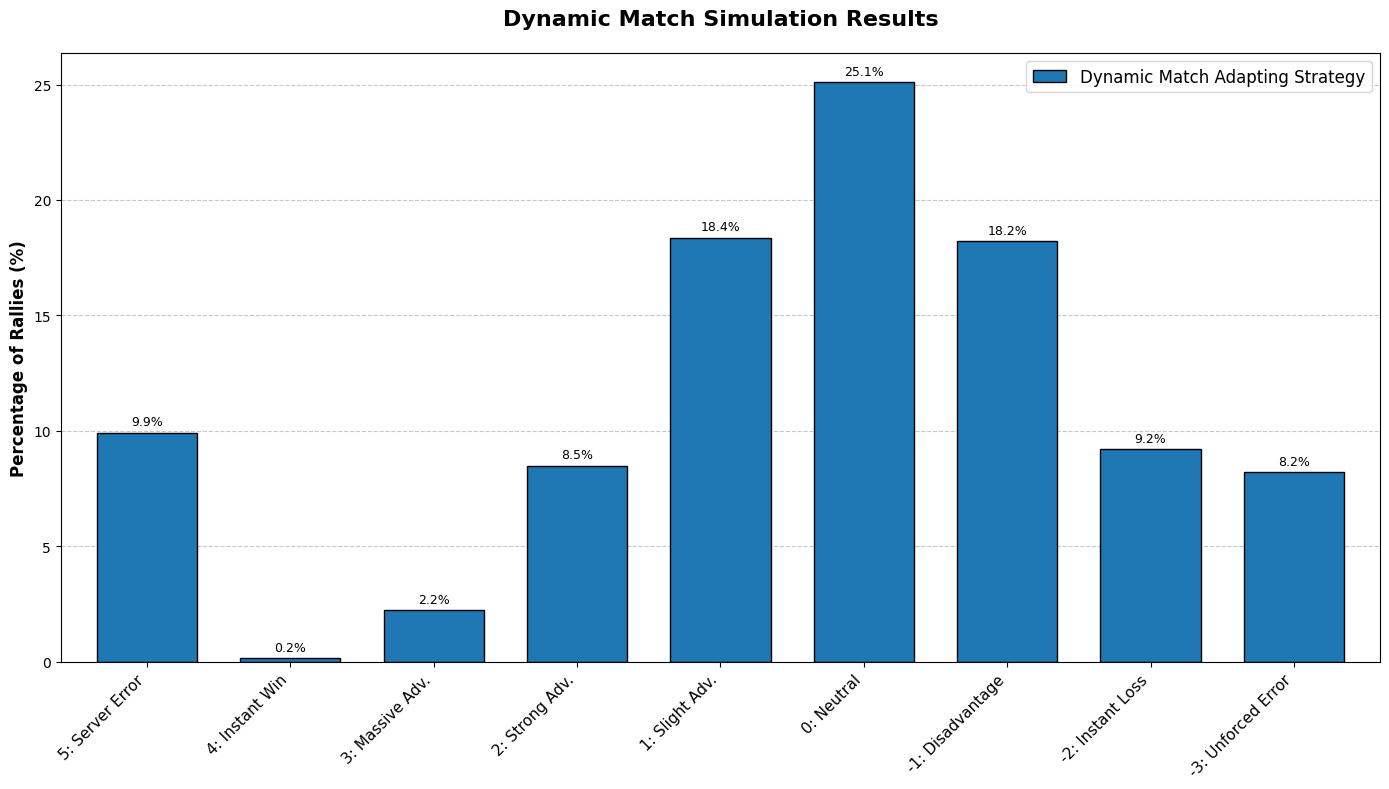

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Using the exact labels from your simulation
SCORE_LABELS = {
    5: "Server Error",
    4: "Instant Win",
    3: "Massive Adv.",
    2: "Strong Adv.",
    1: "Slight Adv.",
    0: "Neutral",
    -1: "Disadvantage",
    -2: "Instant Loss",
    -3: "Unforced Error"
}

def visualize_simulations(simulations_data, title="Badminton Serve Return Outcomes"):
    """
    Takes a dictionary of simulation results, converts to a pandas DataFrame,
    calculates percentages, and generates a bar chart.

    Expected format for simulations_data:
    {
        "Position 0 (Static)": {5: 1011, 4: 186, ...},
        "Position 3 (Static)": {5: 1029, 4: 13, ...}
    }
    OR
    {
        "Dynamic Match Results": {5: 980, 4: 150, ...}
    }
    """

    # 1. Map data to a Pandas DataFrame
    # Missing scores in any dataset will be filled with 0
    df = pd.DataFrame(simulations_data).fillna(0)

    # 2. Convert raw counts to percentages for each column
    for col in df.columns:
        total = df[col].sum()
        if total > 0:
            df[col] = (df[col] / total) * 100

    # 3. Sort index descending so +5 is on the left and -3 is on the right
    df = df.sort_index(ascending=False)

    # 4. Map the integer index to our readable labels
    df.index = df.index.map(lambda x: f"{x}: {SCORE_LABELS.get(x, 'Unknown')}")

    # --- VISUALIZATION ---

    # Plot directly from the DataFrame
    ax = df.plot(kind='bar', figsize=(14, 8), width=0.7, edgecolor='black', colormap='tab10')

    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Percentage of Rallies (%)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_axisbelow(True) # Push gridlines behind bars

    # Auto-label the heights of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Only label bars that actually have data
            ax.annotate(f'{height:.1f}%',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Return the dataframe so you can print or inspect the raw table in Colab
    return df

if __name__ == "__main__":
    # IN COLAB: Make sure you have run your simulation cells first so these functions exist!

    try:
        print("Running NEW Static Simulations to generate fresh data...")
        # Generate fresh dictionaries using your simulation function
        live_results_pos_0 = run_simulation(trials=10000, position=0)
        live_results_pos_3 = run_simulation(trials=10000, position=3)

        # Map the fresh data to the dictionary our chart expects
        live_static_data = {
            "Position 0 (On Line)": live_results_pos_0,
            "Position 3 (Far Back)": live_results_pos_3
        }

        print("\nGenerating Comparative Static Chart with FRESH Data...")
        df_static = visualize_simulations(live_static_data, "Static Positioning Comparison: Pos 0 vs Pos 3")

    except NameError:
        print("\n[!] Error: Could not find 'run_simulation'. Please run the Static Simulation cell first.")

    try:
        print("\n---------------------------------------------------------")
        print("Running NEW Dynamic Match Simulation to generate fresh data...")
        # Generate fresh dictionary using your dynamic match function
        live_dynamic_results = run_dynamic_match(total_rallies=10000, starting_position=1)

        live_dynamic_data = {
            "Dynamic Match Adapting Strategy": live_dynamic_results
        }

        print("\nGenerating Dynamic Match Chart with FRESH Data...")
        df_dynamic = visualize_simulations(live_dynamic_data, "Dynamic Match Simulation Results")

    except NameError:
        print("\n[!] Error: Could not find 'run_dynamic_match'. Please run the Dynamic Simulation cell first.")

## Version 8 (RL Agent Simulation)
- Use Q-Learning for receiver positioning and serve choice

In [ ]:
import random
import pandas as pd

# Define the possible actions the AI can take
# 4 Positions x 3 Guesses = 12 total possible actions
POSITIONS = [0, 1, 2, 3]
GUESSES = ['SHORT', 'FLICK', 'REACT']
ACTIONS = [(pos, guess) for pos in POSITIONS for guess in GUESSES]

# Define the states (what the AI observes before making a decision)
# State = (Previous Serve Type, Did the Server just get punished?)
STATES = [
    ('SHORT', False), ('SHORT', True),
    ('FLICK', False), ('FLICK', True),
    (None, False) # Initial state for the very first rally
]

# Initialize the Q-Table (The AI's "Brain")
# Every State-Action pair starts at a score of 0.0
q_table = {state: {action: 0.0 for action in ACTIONS} for state in STATES}

# Hyperparameters (The knobs that control how the AI learns)
LEARNING_RATE = 0.1       # How quickly the AI overwrites old knowledge with new knowledge
DISCOUNT_FACTOR = 0.8     # How much the AI cares about future rewards vs immediate rewards
EXPLORATION_RATE = 1.0    # Starts at 100% random guessing
EXPLORATION_DECAY = 0.9999 # Slowly decays so the AI starts using what it learned
MIN_EXPLORATION = 0.01    # Never stops exploring completely (1% chance to try something weird)

def get_server_prob(position, state):
    """Calculates server probability, factoring in the Adversarial Adaptation we built earlier."""
    prev_serve, server_adapted = state
    if server_adapted:
        if prev_serve == 'SHORT': return 0.05  # Server got smashed on short, 95% flick next
        if prev_serve == 'FLICK': return 0.95  # Server got smashed on flick, 95% short next
    return SHORT_SERVE_PROBABILITY[position]

def step(action, state):
    """The AI takes an action, the Server responds, and the Environment returns the Reward and Next State."""
    position, guess = action

    # 1. Server Decides
    short_prob = get_server_prob(position, state)
    serve = 'SHORT' if random.random() < short_prob else 'FLICK'

    # 2. Server Executes (Uses logic from Cell 1)
    remaining_prob = 1.0 - SERVER_ERROR_RATE
    quality = random.choices(
        [0, 1, 2, 3],
        weights=[SERVER_ERROR_RATE, remaining_prob * 0.45, remaining_prob * 0.40, remaining_prob * 0.15], k=1
    )[0]

    # 3. Calculate Reward (Uses the evaluate_return function from Cell 1)
    reward = evaluate_return(position, guess, serve, quality)

    # 4. Check for unforced errors
    if -1 <= reward <= 4:
        error_rate = RECEIVER_SHORT_ERROR_RATE if serve == 'SHORT' else RECEIVER_FLICK_ERROR_RATE
        if random.random() < error_rate:
            reward = -3

    # 5. Determine next state (Did the server just suffer an Instant Loss/Score 4?)
    next_state = (serve, reward == 4)

    return reward, next_state

def train_agent(episodes=50000):
    global EXPLORATION_RATE
    print(f"Training AI Agent for {episodes} rallies...")

    state = (None, False)

    for _ in range(episodes):
        # 1. Choose Action (Explore vs Exploit)
        if random.random() < EXPLORATION_RATE:
            action = random.choice(ACTIONS) # Try something random
        else:
            # Pick the action with the highest Q-value for the current state
            action = max(q_table[state], key=q_table[state].get)

        # 2. Take Action & Observe Result
        reward, next_state = step(action, state)

        # 3. Update Q-Table (The Bellman Equation)
        old_value = q_table[state][action]
        next_max = max(q_table[next_state].values())

        # New Q value = Old Value + Learning Rate * (Reward + Discount * Max Future Reward - Old Value)
        new_value = old_value + LEARNING_RATE * (reward + (DISCOUNT_FACTOR * next_max) - old_value)
        q_table[state][action] = new_value

        # 4. Update State and Decay Exploration
        state = next_state
        if EXPLORATION_RATE > MIN_EXPLORATION:
            EXPLORATION_RATE *= EXPLORATION_DECAY

def evaluate_learned_policy():
    """Extracts the best strategy the AI learned and formats it into a readable Pandas DataFrame."""
    print("\n--- AI'S OPTIMAL STRATEGY DISCOVERED ---")

    results = []
    for state in STATES:
        if state[0] is None: continue # Skip the initial empty state

        # Find the action with the highest Q-Value for this state
        best_action = max(q_table[state], key=q_table[state].get)
        best_pos, best_guess = best_action
        expected_value = q_table[state][best_action]

        # Format the state context nicely
        context = "Standard Serve" if not state[1] else f"Adapting (Just got punished on {state[0]})"

        results.append({
            "Context (Opponent State)": context,
            "Best Position": f"Pos {best_pos}",
            "Best Guess": best_guess,
            "Expected Point Value": round(expected_value, 2)
        })

    df = pd.DataFrame(results)
    return df

if __name__ == "__main__":
    # 1. Train the AI (Takes about 1-2 seconds in Colab)
    train_agent(episodes=100000)

    # 2. Display the final "solved" strategy
    df_strategy = evaluate_learned_policy()
    print("\nThe Q-Table has converged! Here is the mathematically optimal way to return serves:")
    display(df_strategy) # 'display' renders a beautiful table automatically in Colab

Training AI Agent for 100000 rallies...

--- AI'S OPTIMAL STRATEGY DISCOVERED ---

The Q-Table has converged! Here is the mathematically optimal way to return serves:


,Context (Opponent State),Best Position,Best Guess,Expected Point Value
0,Standard Serve,Pos 1,FLICK,2.17
1,Adapting (Just got punished on SHORT),Pos 2,REACT,2.40
2,Standard Serve,Pos 2,SHORT,2.40
3,Adapting (Just got punished on FLICK),Pos 1,REACT,1.00
